# Supplementary Material: Constrained Parameter Inference as a Principle for Learning

This notebook allows the reproduction of plots which comprise Figure 3 of this submission.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ZCA Computation
def zca_whiten_data(data):
    ZCAMatrix = zca_whitening_matrix(data.transpose() - np.mean(data.transpose(), axis=0))
    data_transformed = np.dot(ZCAMatrix, data.transpose() - np.mean(data.transpose(), axis=0))

    return data_transformed.transpose()

def zca_whitening_matrix(X):
    """
    Function to compute ZCA whitening matrix (aka Mahalanobis whitening).
    INPUT:  X: [M x N] matrix.
        Rows: Variables
        Columns: Observations
    OUTPUT: ZCAMatrix: [M x M] matrix
    """
    # Covariance matrix [column-wise variables]: Sigma = (X-mu)' * (X-mu) / N
    sigma = np.cov(X, rowvar=True) # [M x M]
    # Singular Value Decomposition. X = U * np.diag(S) * V
    U,S,V = np.linalg.svd(sigma)
        # U: [M x M] eigenvectors of sigma.
        # S: [M x 1] eigenvalues of sigma.
        # V: [M x M] transpose of U
    # Whitening constant: prevents division by zero
    epsilon = 1e-8
    # ZCA Whitening matrix: U * Lambda * U'
    ZCAMatrix = np.dot(U, np.dot(np.diag(1.0/np.sqrt(S + epsilon)), U.T)) # [M x M]

    return ZCAMatrix

In [3]:
# Loading MNIST data
from keras.datasets import mnist

# Loading MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Reshaping to flat digits
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

# Normalizing data
x_train = x_train / 255.0
x_test = x_test / 255.0

## Figure 3A: Input transformation analysis

In [4]:
zca_processed_x_train = zca_whiten_data(x_train)

# Loading COPI-trained network's first lateral decorrelating matrix
R = np.load("./MNIST/copi_decorr/1/0R.npy")
copi_processed_x_train = np.einsum('ij,nj->ni', R, x_train)

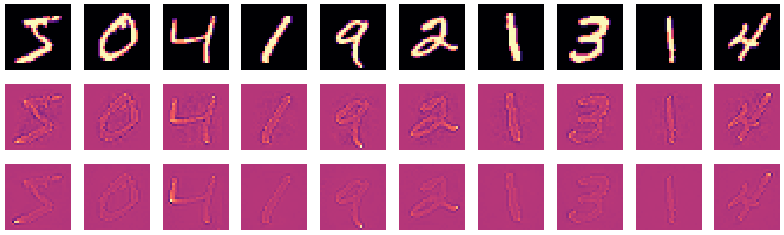

In [5]:
# Number of examples to be plot
nb_examples = 10

# Collecting the set of data to be plotted
data = [x_train - 0.5, copi_processed_x_train, zca_processed_x_train]

# Plotting data in a 10x3 grid
plt.figure(figsize=(nb_examples*2, 2*3), dpi=50)
for e in range(nb_examples):
  for indx, d in enumerate(data):
    plt.subplot(len(data), nb_examples, e+indx*nb_examples+1)
    # Setting the colormap max/min as symmetrical about zero
    minmax = np.max(np.abs(d[:nb_examples]))
    plt.imshow(d[e].reshape(28,28), cmap='magma', vmin=-minmax, vmax=minmax, interpolation='None')
    plt.axis('off')
plt.show()

## Figure 3B: Layer-wise Feature Analysis

In [6]:
def leaky_relu(x, alpha=0.1):
  '''
    Leaky ReLU function, returns scaled input data
    Parameters:
      x (np array): Input data array (assumed NxM)
      alpha (float): Leak term (default 0.1)
    Returns:
      y (np array): A copy of x with all negative values multiplied by alpha
  '''
  y = np.copy(x)
  y[x < 0.0] = alpha*y[x < 0.0]
  return y

def run_copi_network(inputs, Ws, Rs):
  '''
    Simple function to run forward pass in a COPI network
    Parameters:
      inputs (np array): Input data array (assumed NxM)
      Ws (list of np arrays): List of forward weight matrices
      Rs (list of np arrays): list of lateral weight matrices
    Returns:
      state (np array): Network output (at output layer, NxK)
  '''
  state = inputs @ Rs[0].transpose()
  for indx, w in enumerate(Ws):
    state = state @ w.transpose()
    state = leaky_relu(state)
    if (indx == (len(Ws) - 1)):
      continue
    state = state @ Rs[indx + 1].transpose()
  return state

In [7]:
# Loading COPI network's weight matrices
Ws = []
Rs = []

nb_layers = 5
for l in range(nb_layers):
  Rs.append(np.load('./MNIST/copi_decorr/1/' + str(l) + "R.npy"))
  Ws.append(np.load('./MNIST/copi_decorr/1/' + str(l) + "W.npy"))

/tmp/ipykernel_1632984/2718818567.py:11: RuntimeWarning: Mean of empty slice
  var = np.nanmean(var**2, axis=0)


Layer: 1


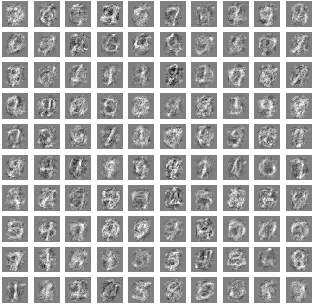

Layer: 2


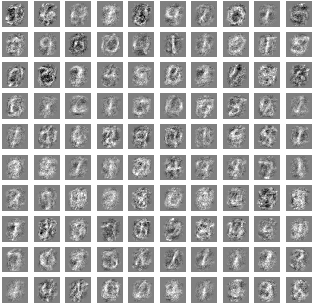

Layer: 3


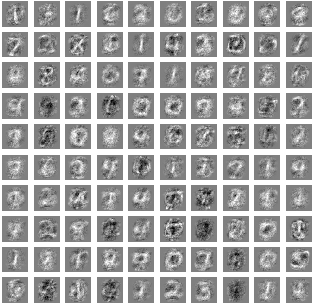

Layer: 4


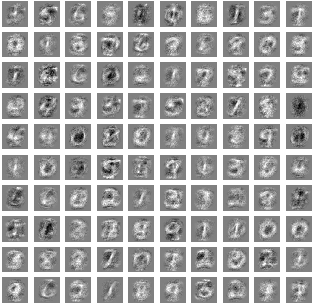

Layer: 5


In [8]:
# Layer whose RFs we wish to infer
nb_layers=5
nb_examples = 100

# Run network for chosen layer's decorrelated inputs
x_0 = x_train @ Rs[0].transpose()
# Computing the variance over the input data (ignoring values less than some epsilon due to MNIST pixel distribution)
var = np.copy(x_0)
epsilon = 1e-2
var[np.abs(var) < epsilon] = np.nan
var = np.nanmean(var**2, axis=0)
var[np.isnan(var)] = 1.0

for layer in range(nb_layers):
  y_l = run_copi_network(x_train, Ws[:(layer+1)], Rs[:layer+1])

  lin_approx = (1/(len(y_l)))*np.einsum('ni,nj->ij', x_0, y_l)
  lin_approx = lin_approx / var [:, np.newaxis]

  size = (np.sqrt(nb_examples)*2, np.sqrt(nb_examples)*2)

  print('Layer: ' + str(layer+1))
  plt.figure(figsize=size, dpi=20)
  for e in range(np.min([lin_approx.shape[1], nb_examples])):
    plt.subplot(int(np.sqrt(nb_examples)), int(np.sqrt(nb_examples)), e+1)
    plt.imshow((lin_approx[:,e].reshape(28,28) / np.max(np.abs(lin_approx[:,e]))), cmap='gray', vmin=-1, vmax=1, interpolation='none')
    plt.axis('off')
  plt.show()

## Figure 3C: Network Compression

In [9]:
# Loading weights from 5 randomly seeded and trained COPI network on MNIST
nb_seeds = 5
nb_layers = 5
Ws_set = [[] for s in range(nb_seeds)]
Rs_set = [[] for s in range(nb_seeds)]

for s in range(nb_seeds):
  for l in range(nb_layers):
    Rs_set[s].append(np.load('./MNIST/copi_decorr/' + str(s+1) + '/' + str(l) + "R.npy"))
    Ws_set[s].append(np.load('./MNIST/copi_decorr/' + str(s+1) + '/'  + str(l) + "W.npy"))

In [10]:
start_layer = 2
train_perfs = [[] for s in range(nb_seeds)]
test_perfs = [[] for s in range(nb_seeds)]

for s in range(nb_seeds):
  for h in range(nb_layers-1):
    end_layer = start_layer + h + 1

    # If there is no change in network structure, keep original network
    if end_layer == (start_layer + 1):
      new_Ws = Ws_set[s]
      new_Rs = Rs_set[s]
    # Otherwise, infer a linear transformation from the 'start_layer', skipping h+1 layers
    else:
      # First compute the decorrelated starting data for the whole training set
      start_data = run_copi_network(x_train, Ws_set[s][:(start_layer - 1)], Rs_set[s][:start_layer]) @ Rs_set[s][start_layer-1].transpose()
      # Next compute the responses of the layer we are targetting from the whole training set
      end_data = run_copi_network(x_train, Ws_set[s][:end_layer-1], Rs_set[s][:end_layer-1])

      # Use correlation to form a linear approximation of the transformation between the start and end layer
      lin_approx_w = (1/(len(start_data)))*np.einsum('ni,nj->ij', end_data, start_data)
      # This must be rescaled by the inverse of the start layer node variances
      var = np.copy(start_data)
      var[var == 0] = np.nan
      var = np.nanmean(var**2, axis=0)
      var[np.isnan(var)] = 1.0
      lin_approx_w = lin_approx_w / var

      # Finally construct a new set of weight matrices for the replacement (compressed) network
      new_Ws = Ws_set[s][:start_layer -1]
      new_Ws.append(lin_approx_w)
      new_Ws.extend([Ws_set[s][e] for e in range(end_layer - 1, len(Ws_set[s]))])

      new_Rs = Rs_set[s][:start_layer]
      new_Rs.extend(Rs_set[s][(end_layer-1):])


    # Check the train and test performance of the compressed networks
    approx_out = run_copi_network(x_train, new_Ws, new_Rs)
    train_perfs[s].append(np.mean(np.argmax(approx_out, axis=1) == y_train))

    approx_out = run_copi_network(x_test, new_Ws, new_Rs)
    test_perfs[s].append(np.mean(np.argmax(approx_out, axis=1) == y_test))

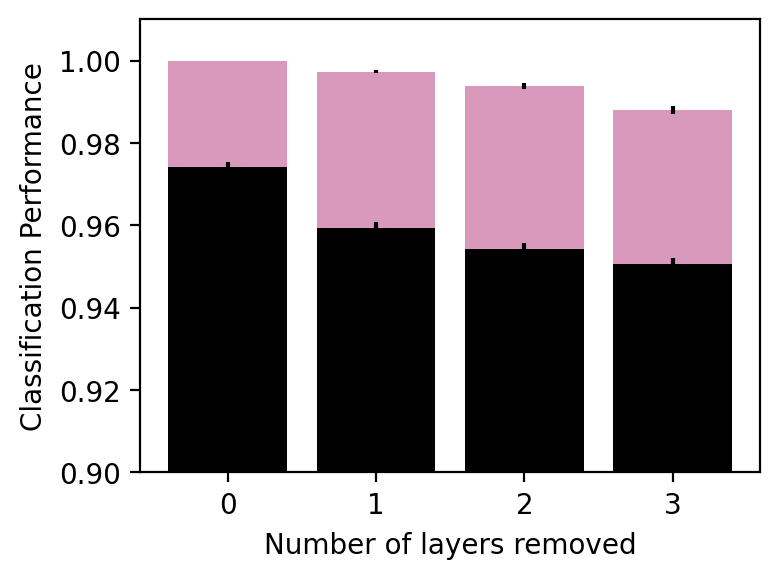

In [11]:
plt.figure(figsize=(4,3), dpi=200)
cmap = plt.get_cmap("magma")

plt.bar(range(0, len(train_perfs[0])), np.mean(train_perfs, axis=0), color=cmap(125), alpha=0.5, yerr=np.std(train_perfs, axis=0))
plt.bar(range(0, len(test_perfs[0])), np.mean(test_perfs, axis=0), color='k', yerr=np.std(test_perfs, axis=0))
plt.ylim([0.9, 1.01])
plt.xlabel('Number of layers removed')
plt.ylabel('Classification Performance')
plt.show()